<a href="https://colab.research.google.com/github/Gabr-iel007/MachineLearning-projects/blob/main/UnsupervisedLearning.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [18]:
import pandas as pd
import numpy as np

df = pd.read_csv("/content/Mall_Customers.csv")
df.head()

df.tail()

df.info()

df.describe()

df.shape

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   CustomerID              200 non-null    int64 
 1   Gender                  200 non-null    object
 2   Age                     200 non-null    int64 
 3   Annual Income (k$)      200 non-null    int64 
 4   Spending Score (1-100)  200 non-null    int64 
dtypes: int64(4), object(1)
memory usage: 7.9+ KB


(200, 5)

In [19]:
df.duplicated().sum()


np.int64(0)

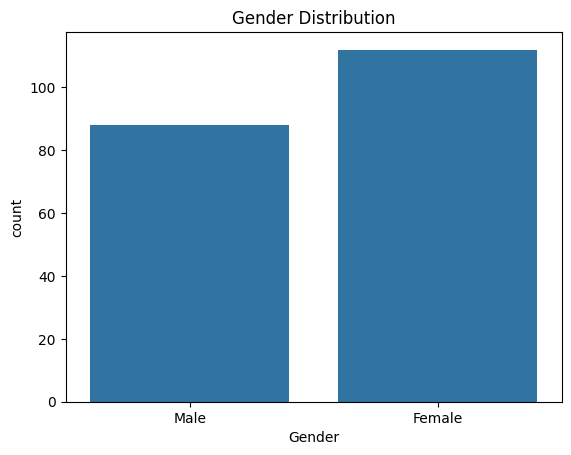

In [20]:
import matplotlib.pyplot as plt
import seaborn as sns
sns.countplot(x ='Gender', data=df)
plt.title("Gender Distribution")
plt.show()

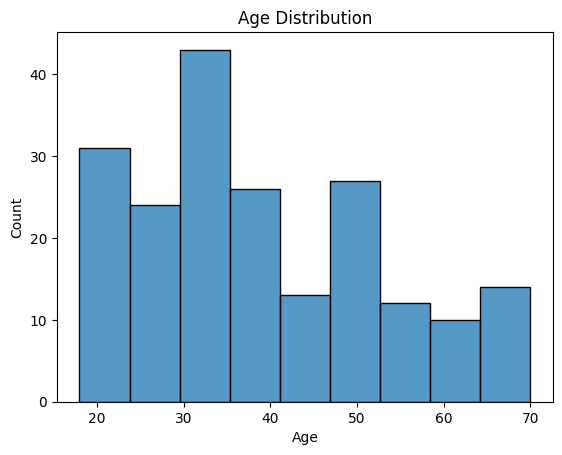

In [21]:
#Age Distribution

sns.histplot(df['Age'],)
plt.title("Age Distribution")
plt.show()


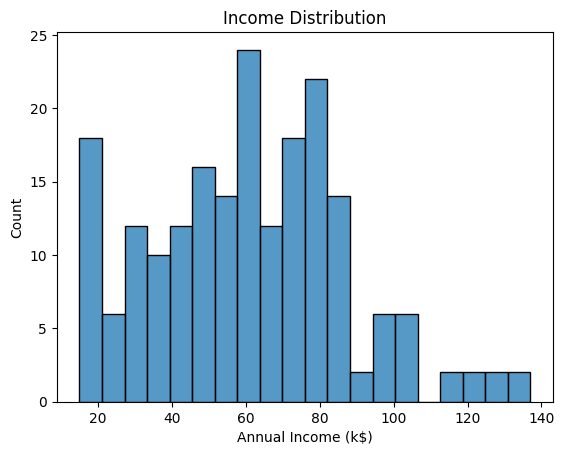

In [22]:
#Income Distribution
sns.histplot(df['Annual Income (k$)'], bins=20)
plt.title("Income Distribution")
plt.show()

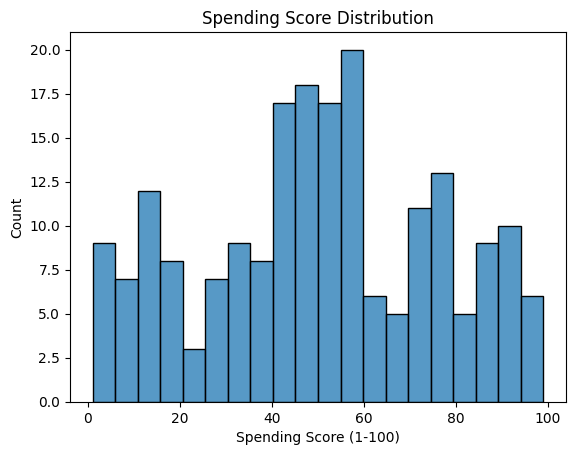

In [23]:
#Spending Score Distribution
sns.histplot(df['Spending Score (1-100)'], bins=20)
plt.title("Spending Score Distribution")
plt.show()

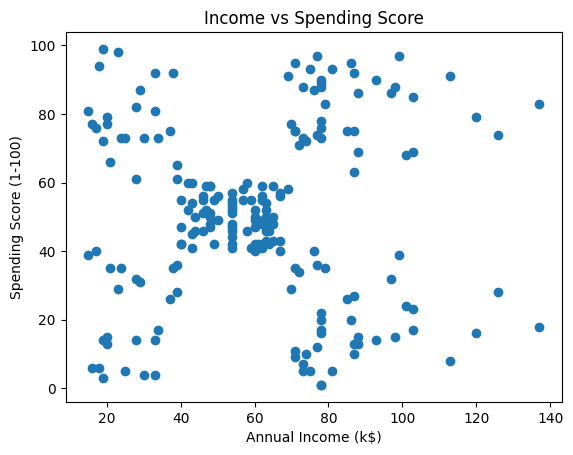

In [24]:
#Income vs Spending
plt.scatter(df['Annual Income (k$)'], df['Spending Score (1-100)'])
plt.title("Income vs Spending Score")
plt.xlabel("Annual Income (k$)")
plt.ylabel("Spending Score (1-100)")
plt.show()

In [25]:
#feature Selection
X = df[
      ["Annual Income (k$)",
      "Spending Score (1-100)"]
  ]

In [26]:
from sklearn.preprocessing import StandardScaler

#feature Scaling
scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

In [27]:
from sklearn.cluster import KMeans

#Elbow Method
#wcss - Within-Cluster Sum of Squares - It tells us how compact or tight our clusters are
wcss = []
for i in range(1, 11):
  kmeans = KMeans(
      n_clusters=i,
      random_state=42,
      n_init=10
      )
  kmeans.fit(X_scaled)

  wcss.append(kmeans.inertia_)

<function matplotlib.pyplot.show(close=None, block=None)>

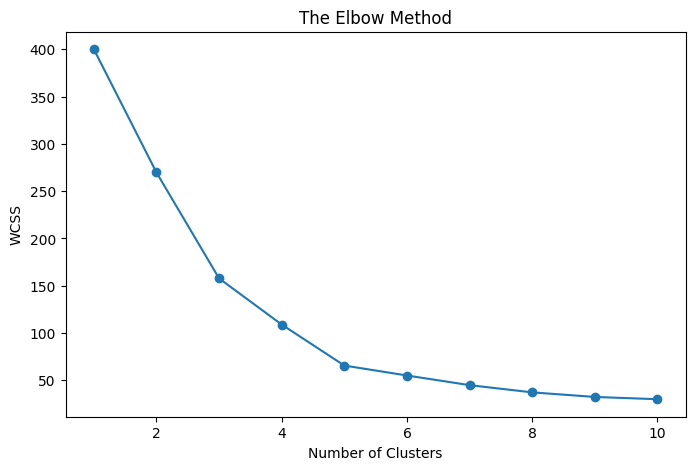

In [28]:
plt.figure(figsize=(8,5))
plt.plot(range(1,11), wcss, marker='o')
plt.title("The Elbow Method")
plt.xlabel("Number of Clusters")
plt.ylabel("WCSS")
plt.show

In [29]:
Kmeans = KMeans(
    n_clusters=5,
    random_state=42,
    n_init=10
    )
clusters = kmeans.fit_predict(X_scaled)

In [30]:
#Adding Cluster Labels

df["Cluster"] = clusters

df.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100),Cluster
0,1,Male,19,15,39,7
1,2,Male,21,15,81,4
2,3,Female,20,16,6,0
3,4,Female,23,16,77,4
4,5,Female,31,17,40,7


In [31]:
print(kmeans.cluster_centers_)

[[-1.37320883 -1.57680239]
 [ 0.1206509  -0.15673077]
 [ 0.68673384  1.241219  ]
 [ 1.87564575 -1.09476801]
 [-1.37766193  0.94724608]
 [ 1.87564575  1.23452563]
 [ 0.7489536  -1.45651437]
 [-1.16645776 -0.60501909]
 [-0.47559109  0.09608336]
 [-1.29368919  1.68744384]]


In [32]:
centers = scaler.inverse_transform(kmeans.cluster_centers_)

centers_df = pd.DataFrame(
    centers,
    columns=[
        "Annual Income (k$)",
        "Spending Score (1-100)"
    ]
)

print(centers_df)

   Annual Income (k$)  Spending Score (1-100)
0           24.583333                9.583333
1           63.720930               46.162791
2           78.551724               82.172414
3          109.700000               22.000000
4           24.466667               74.600000
5          109.700000               82.000000
6           80.181818               12.681818
7           30.000000               34.615385
8           48.100000               52.675000
9           26.666667               93.666667
